In [38]:
import pandas as pd
import numpy as np

import altair as alt

In [39]:
df = pd.read_csv('fec/totals-2020-01-20T18_57_22.csv')
df['cash'] = df['cash_on_hand_end_period'].apply(lambda x: '${:,d}'.format(int(x)))

In [40]:
# df.info()

In [41]:
df = df.sort_values('cash_on_hand_end_period')

In [42]:
df_contribs_1 = pd.read_csv('fec/contribs_pfluger-berryhill.csv')
df_contribs_2 = pd.read_csv('fec/contribs_cady-schumann.csv')

In [43]:
df_conaway = pd.read_csv('fec/conaway.csv')

In [44]:
frames = [df_contribs_1, df_contribs_2, df_conaway]

In [45]:
df_contribs = pd.concat(frames)

In [46]:
# df_contribs.info()

In [47]:
contribs_grouped = df_contribs.groupby('committee_name').contribution_receipt_amount.sum()

In [48]:
# contribs_grouped.to_csv('fec/contribs_sum.csv', headers=True)

In [49]:
contribs = pd.read_csv('fec/contribs_sum.csv')

In [50]:
merged = pd.merge(df, contribs, on='name')

In [51]:
# merged.head()

In [119]:
totals_2019 = pd.read_csv('fec/totals_2019.csv').rename(columns={'debts_owed_by_committee':'Debt', 'cash_on_hand_end_period':'Cash on hand'})
totals_2019 = totals_2019[totals_2019.name != 'Mike Conaway']

totals_2019 = totals_2019.sort_values('Cash on hand').reset_index(drop=True)
# totals_2019 = totals_2019.drop([11])
totals_2019

,name,receipts,disbursements,Cash on hand,Debt
0,Ross Alan Schumann,0.00,0.00,0.00,0.00
1,Brandon Batch,0.00,0.00,0.00,0.00
2,Wesley Virdell,0.00,0.00,0.00,0.00
3,Richard Bartlett,22620.81,22620.81,0.00,0.00
4,Wacey Alpha Cody,0.00,0.00,0.00,0.00
5,Jeffrey Cady,0.00,0.00,0.00,0.00
6,James Berryhill,0.00,0.00,0.00,0.00
7,Ned Luscombe,0.00,0.00,0.00,0.00
8,Casey Gray,0.00,0.00,0.00,0.00
9,James Faircloth,0.00,0.00,0.00,0.00


In [74]:
# totals_2019 = totals_2019.reset_index(drop=False)
# totals_2019

In [54]:
# totals_2019.level_0 = totals_2019.index * 20
# totals_2019

In [120]:
all_totals = pd.merge(totals_2019, contribs, on='name')
# all_totals.rename(columns={'debts_owed_by_committee':'Debts', 'contributions':'Contributions'})
# all_totals.to_csv('fec/all_totals_2019.csv', header=True)
# all_totals.to_json('fec/all_totals_2019.json', orient='index')

In [56]:
# chart.save('vegachart.html')

In [57]:
json = pd.read_json('fec/all_totals_2019.json')

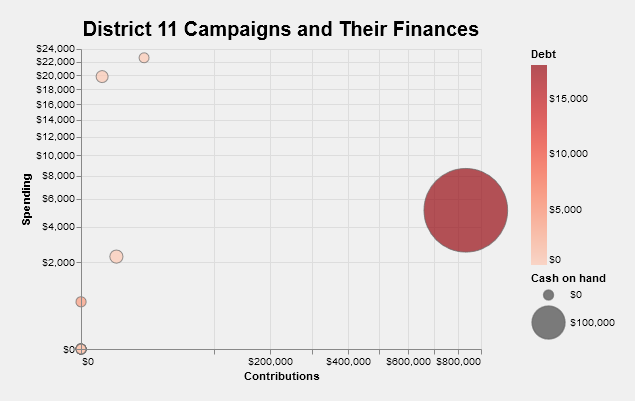

In [128]:
# selection = alt.selection_single(on='mouseover', fields=['name','cash_on_hand_end_period', 'contributions'])

# color = alt.condition(selection,
#                      alt.Color('name:N', legend=None),
#                       alt.value('lightgray')
#                      )

def mult_index(number):
    return number * 10

bubble = alt.Chart(all_totals, title='District 11 Campaigns and Their Finances', padding=20).mark_circle(strokeWidth=1, strokeOpacity=1, stroke='#666666').encode(
    alt.X('contributions:Q',
          scale=alt.Scale(zero=False, type='sqrt'),
          sort='ascending',
          title='Contributions',
         axis=alt.Axis(format="$,.0f")
         ),
    alt.Y('disbursements:Q', 
          scale=alt.Scale(zero=False, type='sqrt'),
          sort='ascending', 
          title='Spending',
         axis=alt.Axis(format="$,.0f")
         ),
    alt.Size('Cash on hand:Q',
             scale=alt.Scale(range=[100, 7000]),
            legend=alt.Legend(
#                 direction='horizontal',
                format="$,.0f",
                values=[0,100000],
#                 orient='bottom',
                tickCount=2
            )
            ),
    tooltip=[
        alt.Tooltip(title='Name', field='name', type='ordinal'),
        alt.Tooltip(title='Contributions', field='contributions', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Cash on hand', field='Cash on hand', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Spending', field='disbursements', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Debt', field='Debt', format="$,.0f", type='ordinal')
    ],
    color = alt.Color(
        'Debt:Q',
        scale=alt.Scale(
            scheme='reds'
        ),
        legend=alt.Legend(
            format="$,.0f",
            offset=50
        )
    ),
#     strokeWidth='1:O'
    
).add_selection(
    selection
).configure_axis(
    gridOpacity=0.3,
    gridColor='cornflowerblue',
    domain=False
).configure_view(
    strokeWidth=1,
    stroke='cornflowerblue',
    strokeOpacity=0.3
).configure_scale(
    minSize=100,
    continuousPadding=4,
    maxOpacity=0.9,
    minOpacity=0.4,
    pointPadding=0.3,
).configure_legend(
    offset=100
).configure(
    background='#f0f0f0'
).configure_title(
    fontSize=20
)

bubble

In [129]:
bubble.save('vegabubble.html', embed_options={'actions': False})